# Phase 1 — Calibrating the prior concentration s to q

Sibling of `1b`, which showed that shrinking the gap $\Delta$ cannot drive $q = P(D_i)$ below $\approx\tfrac12$ for the last-$k$ and posterior-gap criteria. This notebook turns the **other** knob: the prior. It fixes the gap $\Delta$ and horizon $T$ and sweeps the prior concentration $s$ in $\mathrm{Beta}(s,s)$, Monte-Carloing $q$ under both criteria, producing a curve $q(s)$ and an **inverse** $s(q)$ so you can pick the prior that yields a target such as $q = 0.05$.

Key fact this notebook makes precise: a tight prior pins both posteriors near $\tfrac12$, so the **posterior-gap** criterion (an epistemic test, "did beliefs separate by $\ge \delta$?") collapses toward $0$ and *does* reach $0.05$, whereas the **last-$k$** criterion (a behavioral test, "which arm got pulled?") stays near $\tfrac12$ and does not. The inversion targets posterior-gap; last-$k$ is plotted for contrast.

**Restart-and-Run-All-safe.** The sweep is wrapped in `%%time`; `tqdm` shows progress. Flip `SMOKE_TEST = True` for a fast end-to-end check.

## Setup

Local-only (no Colab/Drive). Imports from `model/` in the parent paper folder.

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq
from tqdm.auto import tqdm

PAPER_ROOT = Path.cwd().resolve().parent
if str(PAPER_ROOT) not in sys.path:
    sys.path.insert(0, str(PAPER_ROOT))
RESULTS_DIR = PAPER_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

from model.bandit import ARM_A, ARM_B, BernoulliBandit
from model.discovery import discovered_by_last_k, discovered_by_posterior_gap
from model.simulation import run_simulation


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/ignacio/anaconda3/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/ignacio/anaconda3/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/ignacio/anaconda3/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/ignacio/anaconda3/lib/python3.10/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/ignacio/anaconda3/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/ignacio/anaconda3/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/ignacio/anaconda3/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/ignacio/anaconda3/lib/python3.10/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  

AttributeError: _ARRAY_API not found

## Parameters

The gap and horizon are now held **fixed** and the prior strength is the swept knob. The calibration is conditional on `GAP` and `N_STEPS`: retarget at a different gap or horizon by changing them and re-running. `S_GRID` is log-spaced and chosen to bracket where posterior-gap $q$ crosses the target.

In [2]:
SMOKE_TEST = False         # True -> tiny run for kernel-restart smoke tests

# Fixed context: arms centered at P_MID, pulled apart by GAP.
P_MID = 0.5
GAP   = 0.01               # Delta = p_A - p_B  (p_A=0.505, p_B=0.495 by default)

# Monte Carlo budget. Each agent is an i.i.d. draw of D_i in the unaided
# regime, so N_AGENTS is the number of samples of q per prior strength.
N_AGENTS = 300 if SMOKE_TEST else 1500
N_STEPS  = 80  if SMOKE_TEST else 200      # horizon T (held fixed across sweep)

# The swept knob: prior is Beta(s, s) per arm (uniform-but-concentrated as s
# grows). s=1 is the flat Beta(1,1) baseline; large s pins beliefs near 1/2.
# Grid stops at 200: posterior-gap q has already reached ~0 by then, so
# larger s adds nothing.
if SMOKE_TEST:
    S_GRID = np.array([1, 20, 100, 200])
else:
    S_GRID = np.array([1, 5, 10, 20, 50, 100, 150, 200])

# Discovery-criterion tolerances (held fixed).
LAST_K_WINDOW = 20         # last-k: last k pulls all arm A
GAP_DELTA     = 0.05       # posterior gap: E[p_A|h] - E[p_B|h] >= GAP_DELTA

TARGET_Q    = 0.05         # the q we want to hit by choosing s
MASTER_SEED = 2026

print(f'SMOKE_TEST={SMOKE_TEST}  gap={GAP}  n_agents/s={N_AGENTS}  n_steps={N_STEPS}  '
      f'#s={len(S_GRID)}  target_q={TARGET_Q}  seed={MASTER_SEED}')

SMOKE_TEST=False  gap=0.01  n_agents/s=1500  n_steps=200  #s=8  target_q=0.05  seed=2026


## Discovery criteria (vectorized)

Same vectorized forms of `discovered_by_last_k` and `discovered_by_posterior_gap` as `1b`; the next cell asserts they match the per-agent module functions on a sample.

In [3]:
def discovery_masks(histories, final_alpha_beta, *, k, delta):
    """Vectorized last-k and posterior-gap criteria over a whole community.

    histories:        (M, T, 2) int   rows [arm_pulled, outcome]
    final_alpha_beta: (M, 2, 2) float per-agent final Beta params
    Returns {criterion -> (M,) bool array of D_i outcomes}.
    """
    last_k = np.all(histories[:, -k:, 0] == ARM_A, axis=1)
    means = final_alpha_beta[:, :, 0] / final_alpha_beta.sum(axis=2)
    gap = (means[:, ARM_A] - means[:, ARM_B]) >= delta
    return {'last_k': last_k, 'posterior_gap': gap}

In [4]:
_chk = run_simulation(BernoulliBandit(p_a=0.6, p_b=0.4),
                      n_agents=50, n_steps=60, seed=0)
_vec = discovery_masks(_chk.histories, _chk.final_alpha_beta,
                       k=LAST_K_WINDOW, delta=GAP_DELTA)
_ref_lastk = np.array([
    discovered_by_last_k(_chk.histories[i], _chk.final_alpha_beta[i], k=LAST_K_WINDOW)
    for i in range(_chk.n_agents)])
_ref_gap = np.array([
    discovered_by_posterior_gap(_chk.histories[i], _chk.final_alpha_beta[i], delta=GAP_DELTA)
    for i in range(_chk.n_agents)])
assert np.array_equal(_vec['last_k'], _ref_lastk)
assert np.array_equal(_vec['posterior_gap'], _ref_gap)
print('vectorized criteria match discovery.py on the sample')

vectorized criteria match discovery.py on the sample


## Run the prior-strength sweep

For each $s$ we run one community of `N_AGENTS` independent agents that all start from a shared $\mathrm{Beta}(s,s)$ prior on each arm, at the fixed gap `GAP` for `N_STEPS` steps, and record $\hat q$ with its binomial standard error under each criterion.

In [5]:
%%time
p_a = P_MID + GAP / 2
p_b = P_MID - GAP / 2
bandit = BernoulliBandit(p_a=p_a, p_b=p_b)

ss = np.random.SeedSequence(MASTER_SEED)
s_seeds = [int(x.generate_state(1)[0]) for x in ss.spawn(len(S_GRID))]

rows = []
for s, seed in zip(tqdm(S_GRID, desc='prior sweep'), s_seeds):
    prior = np.array([[s, s], [s, s]], dtype=float)
    res = run_simulation(bandit=bandit, n_agents=N_AGENTS, n_steps=N_STEPS,
                         prior_alpha_beta=prior, seed=seed)
    masks = discovery_masks(res.histories, res.final_alpha_beta,
                            k=LAST_K_WINDOW, delta=GAP_DELTA)
    for name, mask in masks.items():
        q = float(mask.mean())
        rows.append({
            's': float(s), 'criterion': name, 'q_hat': q,
            'se': float(np.sqrt(q * (1 - q) / N_AGENTS)),
        })

calib = pd.DataFrame(rows)
calib_wide = calib.pivot(index='s', columns='criterion', values='q_hat')
calib_wide

prior sweep:   0%|          | 0/8 [00:00<?, ?it/s]

CPU times: user 1min 41s, sys: 540 ms, total: 1min 41s
Wall time: 1min 42s


criterion,last_k,posterior_gap
s,,
1.0,0.526667,0.486000
5.0,0.518667,0.403333
10.0,0.512000,0.326667
20.0,0.494667,0.206000
50.0,0.504667,0.058000
100.0,0.495333,0.011333
150.0,0.488000,0.000000
200.0,0.480667,0.000000


## The calibration curve $q(s)$

figure -> results/phase1_prior_q_curve_20260530_190542.png


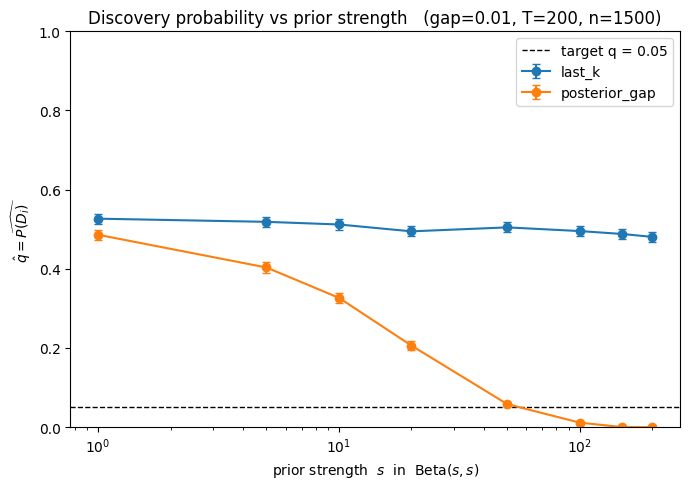

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, grp in calib.groupby('criterion'):
    ax.errorbar(grp['s'], grp['q_hat'], yerr=grp['se'],
                marker='o', capsize=3, label=name)
ax.axhline(TARGET_Q, color='black', ls='--', lw=1, label=f'target q = {TARGET_Q}')
ax.set_xscale('log')
ax.set_xlabel(r'prior strength  $s$  in  $\mathrm{Beta}(s,s)$')
ax.set_ylabel(r'$\hat q = \widehat{P(D_i)}$')
ax.set_title(f'Discovery probability vs prior strength   (gap={GAP}, T={N_STEPS}, n={N_AGENTS})')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
fig_path = RESULTS_DIR / f'phase1_prior_q_curve_{stamp}.png'
plt.savefig(fig_path, dpi=150)
print(f'figure -> {fig_path.relative_to(PAPER_ROOT)}')
plt.show()

## Invert: which prior strength s gives a target q?

We fit a monotone-aware (PCHIP) interpolant $q(s)$ per criterion and invert it by a sign-change scan plus a bracketed root find (robust to the small non-monotone bump posterior-gap shows at low $s$, and to MC noise). `s_for_q(target)` returns the prior strength realising `target`, or `None` if `target` is outside the range of $q$ on the grid.

In [7]:
def make_inverter(s_grid, q_vals):
    """Return (s_for_q, (q_min, q_max)) for one criterion.

    PCHIP interpolation of q(s); inversion by scanning for the first sign
    change of q(s) - target (robust to non-monotonicity), then brentq.
    s_for_q(target) -> the s giving q = target, or None when target is
    outside the achievable range [q_min, q_max] spanned by the grid.
    """
    order = np.argsort(s_grid)
    s = np.asarray(s_grid)[order]
    q = np.asarray(q_vals)[order]
    f = PchipInterpolator(s, q)
    q_min, q_max = float(q.min()), float(q.max())

    def s_for_q(target):
        if not (q_min <= target <= q_max):
            return None
        g = lambda x: float(f(x)) - target
        xs = np.linspace(s[0], s[-1], 800)
        vals = np.array([g(x) for x in xs])
        crossings = np.where(np.diff(np.sign(vals)) != 0)[0]
        if len(crossings) == 0:
            return float(xs[np.argmin(np.abs(vals))])
        i = crossings[0]
        return float(brentq(g, xs[i], xs[i + 1]))

    return s_for_q, (q_min, q_max)


print(f'Prior strength s needed for q = {TARGET_Q}  '
      f'(gap={GAP}, T={N_STEPS}, k={LAST_K_WINDOW}, gap_delta={GAP_DELTA}):')
print()

inverters = {}
for name, grp in calib.groupby('criterion'):
    inv, (q_min, q_max) = make_inverter(grp['s'].values, grp['q_hat'].values)
    inverters[name] = inv
    s_star = inv(TARGET_Q)
    if s_star is None:
        print(f'  {name:14s}:  q stays in [{q_min:.3f}, {q_max:.3f}] over the grid; '
              f'q={TARGET_Q} is OUT OF RANGE.')
    else:
        print(f'  {name:14s}:  s ~ {s_star:.1f}   '
              f'(prior Beta({s_star:.0f}, {s_star:.0f}) per arm)')

Prior strength s needed for q = 0.05  (gap=0.01, T=200, k=20, gap_delta=0.05):

  last_k        :  q stays in [0.481, 0.527] over the grid; q=0.05 is OUT OF RANGE.
  posterior_gap :  s ~ 55.1   (prior Beta(55, 55) per arm)


## Save

Persist the calibration as a timestamped CSV under [`results/`](../results/) so the $s \leftrightarrow q$ map can be reused without recomputing.

In [8]:
stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
csv_path = RESULTS_DIR / f'phase1_prior_q_calibration_{stamp}.csv'
calib.to_csv(csv_path, index=False)
print(f'calibration table -> {csv_path.relative_to(PAPER_ROOT)}')
print(f'figure            -> {fig_path.relative_to(PAPER_ROOT)}')

calibration table -> results/phase1_prior_q_calibration_20260530_190542.csv
figure            -> results/phase1_prior_q_curve_20260530_190542.png


## What this shows, and how to use it

- **Prior concentration is the knob for $q=0.05$ — for posterior-gap.** As $s$ grows the prior pins both posteriors near $\tfrac12$, the belief gap rarely clears $\delta$, and $q_{\text{posterior-gap}}$ falls through the target. The inversion cell reports the $s$ that hits $q=0.05$ at this gap and horizon; read future targets straight off it (or off the saved CSV).
- **Last-$k$ cannot be lowered this way.** It is a behavioral test — the agent still commits to one arm whatever its beliefs do — so $q_{\text{last-}k}$ stays near $\tfrac12$ (it even rises with $s$, since damped noise helps it lock onto the genuinely better arm). To make last-$k$ rare you need a *short horizon* (T close to $k$), not a tighter prior. That is a separate calibration.
- **A caveat for §1.** Last-$k$ and posterior-gap, described there as asymptotically equivalent, decouple sharply in this regime (tight prior, finite $T$): one stays near $\tfrac12$ while the other collapses to $0$. The equivalence is a $T\to\infty$, fixed-prior statement.
- **Interpretation.** A large-$s$ prior models agents who are a priori confident the arms are similar and need substantial evidence to be moved; at horizon $T$ they mostly fail the epistemic discovery test. That is the regime in which individual discovery is genuinely rare while, by §2's independence argument, the community still very likely discovers $A$.
- **Retargeting.** Change `GAP` or `N_STEPS` and re-run to recalibrate $s$ for a different fixed context.